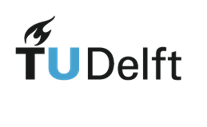




<div style="text-align: center">CIEM5110 â€“ unit 3 â€“ Measurement and Analysis of Vibrations<br>
    Assignment report : <b>Experimental modal analysis of a suspended beam</b></div>


<div style="text-align: center"><b>Deadline</b>: 11 April 2025, 23:59 hrs</div>

***

# Group # (fill in your group number)

**Names**

Jose Orlando Mejia Sanchez

Mohammed Wasay

Xingqi Zhou

**Student numbers**

6457037

6416071

6543480


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
import math

# Problem set 1: signal processing

### Exercise 1.1. Time domain signals
**a**. Plot the hammer force $F_2$ in the time domain and indicate two artefacts in the plot.

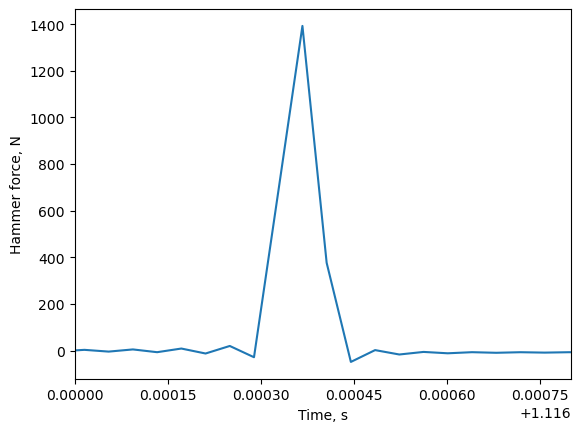

In [3]:
# import data form csv file
data_acc2T1 = pd.read_csv('data1/acc2T1.csv', skiprows=3).to_numpy()
data_acc2T2 = pd.read_csv('data1/acc2T2.csv', skiprows=3).to_numpy()
data_acc2T3 = pd.read_csv('data1/acc2T3.csv', skiprows=3).to_numpy()
data_acc2T4 = pd.read_csv('data1/acc2T4.csv', skiprows=3).to_numpy()
data_acc2T5 = pd.read_csv('data1/acc2T5.csv', skiprows=3).to_numpy()

t_F2 = np.column_stack([
    data_acc2T1[:, 0],
    data_acc2T2[:, 0],
    data_acc2T3[:, 0],
    data_acc2T4[:, 0],
    data_acc2T5[:, 0],
])
F_2 = np.column_stack([
    data_acc2T1[:, 1],
    data_acc2T2[:, 1],
    data_acc2T3[:, 1],
    data_acc2T4[:, 1],
    data_acc2T5[:, 1],
])

# Plot F_2 vs time
plt.plot(t_F2[:, 0], F_2[:, 0], label='T1')
plt.xlabel('Time, s')
import matplotlib.ticker as ticker
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.00015))


plt.ylabel('Hammer force, N')
plt.xlim(1.116 , 1.1168) # use plt.xlim and plt.ylim to control the plot region to identify possible artefacts
plt.show()

*First artefact:* Small oscillations appear before and after the main peak.

*Second artefact:* The impact force has a time duration, which is not ideal for a hammer force signal.

**b**. What is the duration of the impulse $F_2$? What is the approximate frequency range that can be well excited by this force based on this impulse duration? 

In [4]:
# Duration of the impulse (estimated from the zoomed plot)
t_impact = 0.00045 - 0.00029  # approximately 0.16 ms
f_max = 1 / t_impact

print(f"Impulse duration: {t_impact*1000:.2f} ms")
print(f"Approximate usable frequency range: 0 to {f_max:.0f} Hz")

Impulse duration: 0.16 ms
Approximate usable frequency range: 0 to 6250 Hz


**The frequency range is up to 6250Hz. This is because the range is between 0 and 1/T. T = 0.16 ms which results in the frequency range of 6250 HZ**

**c**. Plot the five repeated impact forces for $F_2$. Identify the two impacts with the maximum and minimum peak forces among the five, denoted as $F_{2,max}$ and $F_{2,min}$, respectively. Plot the acceleration $a_{22}$ for these two impacts, denoated as $a_{22,max}$ and $a_{22,min}$, respectively.What are the main differences between the two acceleration signals and why?

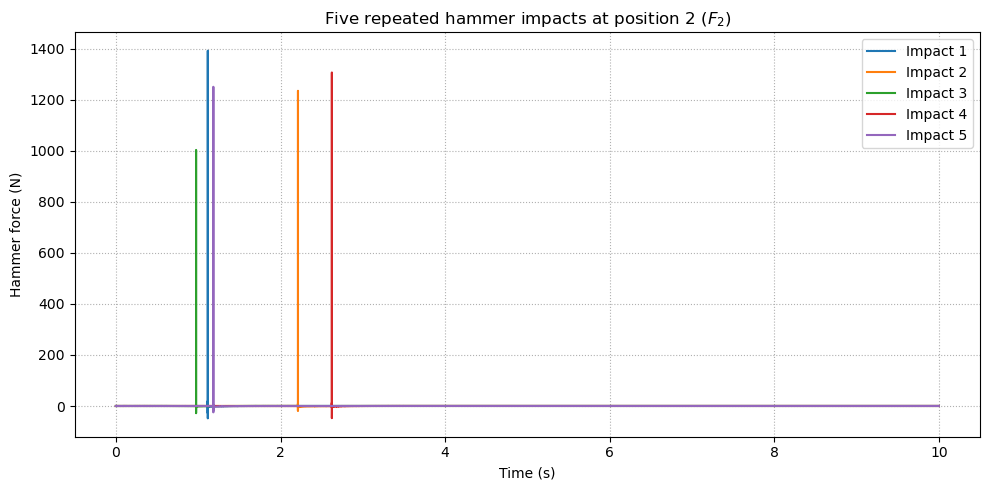

Impact 1 has the largest peak force:  1392.52 N
Impact 3 has the smallest peak force: 1003.66 N


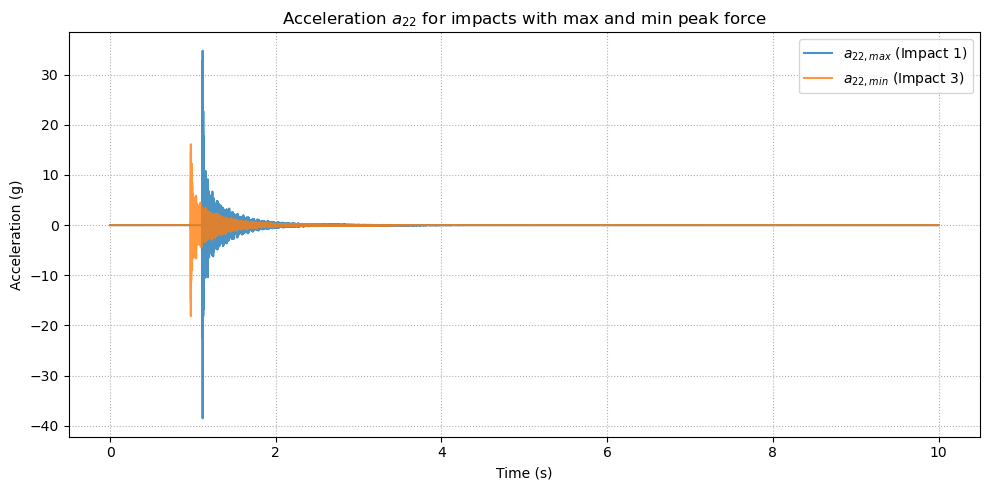

In [6]:
# Plot F_2 for all 5 impacts
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.plot(t_F2[:, i], F_2[:, i], label=f'Impact {i+1}')
plt.xlabel('Time (s)')
plt.ylabel('Hammer force (N)')
plt.title(r'Five repeated hammer impacts at position 2 ($F_2$)')
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

# Identify max and min peak forces
peak_forces = np.max(F_2, axis=0)
max_idx = np.argmax(peak_forces)
min_idx = np.argmin(peak_forces)
print(f"Impact {max_idx+1} has the largest peak force:  {peak_forces[max_idx]:.2f} N")
print(f"Impact {min_idx+1} has the smallest peak force: {peak_forces[min_idx]:.2f} N")

# Extract acceleration at position 2 (column index 5)
acc2 = np.column_stack([
    data_acc2T1[:, 5], data_acc2T2[:, 5], data_acc2T3[:, 5],
    data_acc2T4[:, 5], data_acc2T5[:, 5],
])
t_acc2 = np.column_stack([
    data_acc2T1[:, 4], data_acc2T2[:, 4], data_acc2T3[:, 4],
    data_acc2T4[:, 4], data_acc2T5[:, 4],
])

# Plot a22 for the max and min impacts
plt.figure(figsize=(10, 5))
plt.plot(t_acc2[:, max_idx], acc2[:, max_idx],
         label=f'$a_{{22,max}}$ (Impact {max_idx+1})', alpha=0.8)
plt.plot(t_acc2[:, min_idx], acc2[:, min_idx],
         label=f'$a_{{22,min}}$ (Impact {min_idx+1})', alpha=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.title(r'Acceleration $a_{22}$ for impacts with max and min peak force')
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

**The main differences between the two acceleration signals are that the maximum impact force generates more energy, resulting in a higher amplitude and longer vibration duration in the acceleration signal compared to the minimum impact force.**

### Exercise 1.2. Fourier transform and power spectral density (PSD)
**a**. Plot the positive part of the double-sided Fourier amplitude spectrums of the five forces in one figure in log-log scale. Explain the similarities and differences between different force spectrums.

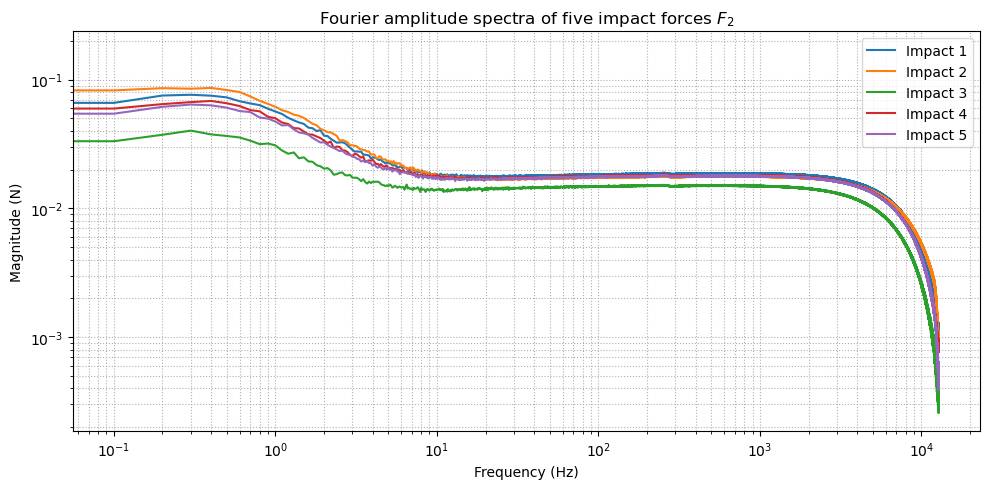

In [9]:
sf = 25600
N_sig = F_2.shape[0]
freq = fftfreq(N_sig, 1/sf)[:N_sig//2]

# FFT of each force - plot in log-log scale
plt.figure(figsize=(10, 5))
for ii in range(5):
    fft_force = fft(F_2[:, ii])
    plt.loglog(freq, 2.0/N_sig * np.abs(fft_force[:N_sig//2]), label=f'Impact {ii+1}')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (N)')
plt.title(r'Fourier amplitude spectra of five impact forces $F_2$')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

*Similarities:* For the five forces, they show similar trends because of the similar mechanisms at each play. The amplitude remains relatively constant at frequencies below 1 Hz, decreases in the range of 1–10 Hz, becomes stable again between 10 and 5000 Hz, after the frequency around 6250Hz, the amplitude drops sharply beyond 10,000 Hz. This is because the hammer impact is very short in duration, and most of the energy is concentrated in the low-frequency range.

*Differences:* Differences between the spectra are mainly in amplitude due to the varying input forces.

**b**. List the first three natural frequencies calculated by the analytical model.

In [11]:
# Rail properties
E = 210e9          # Young's modulus [Pa]
rho = 7850         # Density [kg/m^3]
I = 2337.9e-8      # Moment of inertia [m^4]   (2337.9 cm^4 -> m^4)
A = 69.77e-4       # Cross-sectional area [m^2] (69.77 cm^2 -> m^2)

# Measured beam length
L = 3.0            # [m] beam length

# Free-free beam values: beta_n * L
betaL = np.array([4.730041, 7.853205, 10.995608])

# beta_n
beta = betaL / L

# Natural frequencies in rad/s
omega_n = (betaL**2) * np.sqrt(E * I / (rho * A * L**4))

# Natural frequencies in Hz
f_n = omega_n / (2 * np.pi)

print("Natural frequencies (rad/s):", omega_n)
print("Natural frequencies (Hz):", f_n)

for i, f in enumerate(f_n, start=1):
    print(f"Mode {i}: {f:.2f} Hz")


Natural frequencies (rad/s): [ 744.28749782 2051.65712316 4022.06801763]
Natural frequencies (Hz): [118.45703436 326.53137268 640.13200646]
Mode 1: 118.46 Hz
Mode 2: 326.53 Hz
Mode 3: 640.13 Hz


**c**. Calculate the Fourier transform of $a_{22,max}$ and $a_{22,min}$. Plot the positive part of the double-sided Fourier amplitude spectrums of the two accelerations in one figure in log-log scale. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Explain the similarities and differences between the two spectrums.

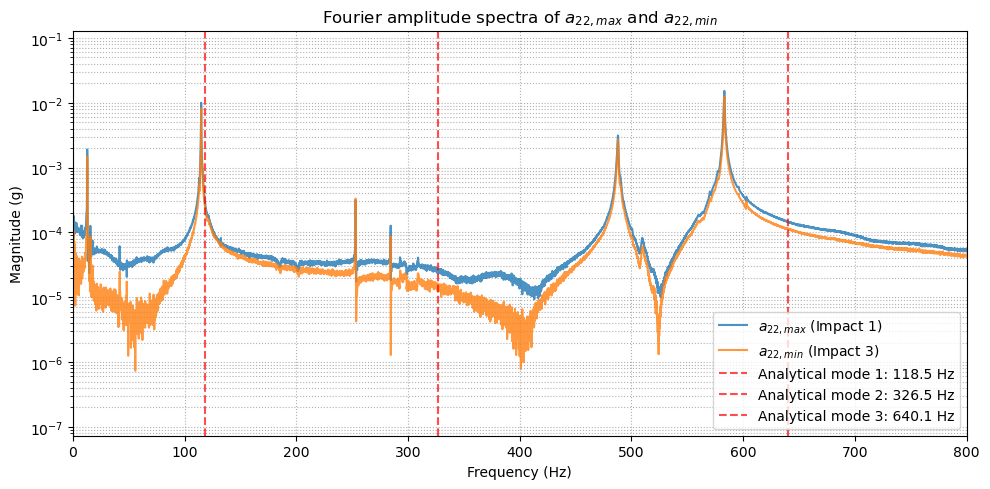

In [12]:
N_sig = acc2.shape[0]
freq = fftfreq(N_sig, 1/sf)[:N_sig//2]

# FFT of a22,max and a22,min
fft_acc_max = fft(acc2[:, max_idx])
fft_acc_min = fft(acc2[:, min_idx])

plt.figure(figsize=(10, 5))
plt.semilogy(freq, 2.0/N_sig * np.abs(fft_acc_max[:N_sig//2]),
             label=f'$a_{{22,max}}$ (Impact {max_idx+1})', alpha=0.8)
plt.semilogy(freq, 2.0/N_sig * np.abs(fft_acc_min[:N_sig//2]),
             label=f'$a_{{22,min}}$ (Impact {min_idx+1})', alpha=0.8)
plt.xlim(0, 800)

# Mark analytical natural frequencies
for i, f in enumerate(f_n):
    plt.axvline(f, color='r', linestyle='--', alpha=0.7,
                label=f'Analytical mode {i+1}: {f:.1f} Hz')

plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (g)')
plt.title(r'Fourier amplitude spectra of $a_{22,max}$ and $a_{22,min}$')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

**Both spectra show three clear peaks at the same frequencies, which correspond to the natural frequencies of the beam. This indicates that the natural frequency is independent of the excitation. Between the peaks, antiresonances are observed, which are caused by the interaction of different vibration modes.**

**However, The amplitudes of the peaks differ between the two spectra, mainly due to the difference in the input force. Slight differences in the antiresonance frequencies are observed, which can be attributed to measurement noise.**

**d**. Calculate the Welch periodogram of the PSD of $a_{22,max}$. Plot the periodogram in log-log scale. 

- Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies.

- Use a rectangular window with different lengths to see its effect. (set the argument `nperseg` with different values)

- Compare the Welch periodogram  and Fourier spectrum of $a_{22,max}$,and explain the main differences between the two.

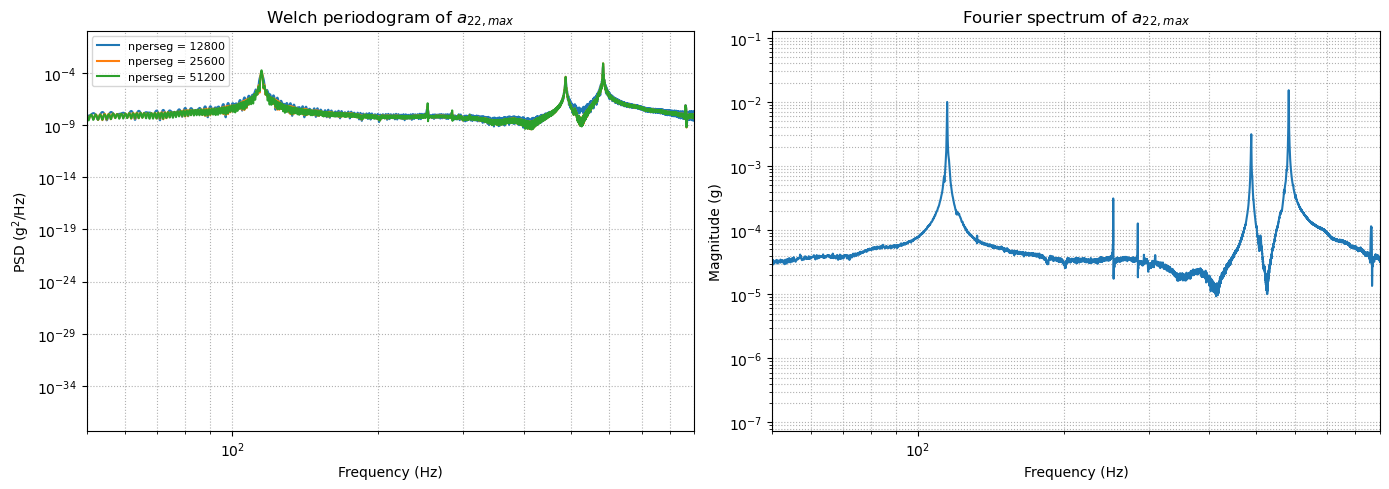

In [13]:
# a22,max
a22_max = acc2[:, max_idx]
N_sig = a22_max.shape[0]
N_fft = N_sig
N_overlap = 0

# Welch periodogram with different rectangular window lengths
window_lengths = [N_sig // 20, N_sig // 10, N_sig // 5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Welch periodograms with different nperseg
for N_window in window_lengths:
    fxx_w, pxx_w = signal.welch(a22_max, sf, window='boxcar',
                                nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
    axes[0].loglog(fxx_w, pxx_w, label=f'nperseg = {N_window}')

axes[0].set_xlim(50, 900)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel(r'PSD (g$^2$/Hz)')
axes[0].set_title(r'Welch periodogram of $a_{22,max}$')
axes[0].legend(fontsize=8)
axes[0].grid(True, which='both', ls=':')

# Fourier spectrum for comparison
fft_a22 = fft(a22_max)
freq = fftfreq(N_sig, 1/sf)[:N_sig//2]
amp_fft = 2.0/N_sig * np.abs(fft_a22[:N_sig//2])

axes[1].loglog(freq[1:], amp_fft[1:])
axes[1].set_xlim(50, 900)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (g)')
axes[1].set_title(r'Fourier spectrum of $a_{22,max}$')
axes[1].grid(True, which='both', ls=':')

plt.tight_layout()
plt.show()

**Comparing the two plots, it can be observed that peaks appear at the same frequency locations in both spectra, and antiresonances can be identified between the peaks. In addition, the amplitude units are different: the Welch spectrum represents the power spectral density (g^2/Hz), while the Fourier spectrum represents the amplitude (g).**

**The main difference between the two is the sharpness of the peaks. The peaks in the Welch spectrum are less sharp than those in the Fourier spectrum. This is because the Welch method divides the signal into multiple segments and computes the FFT of each segment before averaging, whereas the Fourier spectrum is obtained by directly applying the FFT to the entire signal. As a result, the Welch method reduces the frequency resolution, making the peak frequencies less clearly defined compared to the Fourier spectrum.**

### Exercise 1.3. Signal alignment, windowing and zero-padding

**a. (Force window)** Choose one impact force, apply a force window, and plot the windowed and orginal signals in the same figure to show the differences.

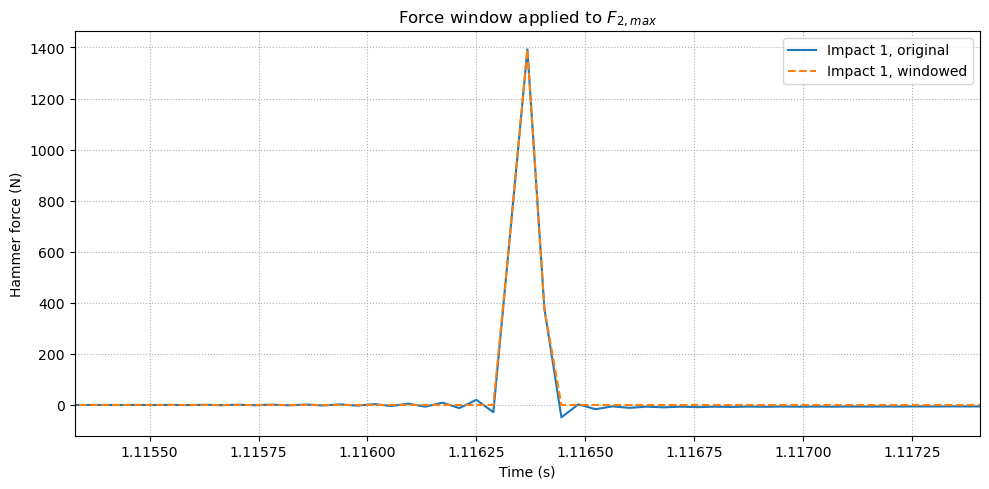

In [14]:
# Find the impacts with maximum and minimum peak force
peak_forces = np.max(F_2, axis=0)
max_idx = np.argmax(peak_forces)
min_idx = np.argmin(peak_forces)

# Use F_2,max as the example
force_signal = F_2[:, max_idx]
time_signal = t_F2[:, max_idx]

# Define a trigger force
force_trigger = 50

# Get indices where force exceeds trigger
idx_boolean = force_signal > force_trigger
idx_triggered = np.where(idx_boolean)[0]

# Define a rectangular (force) window
rec_win = np.zeros(len(force_signal))
rec_win[idx_triggered] = 1
f_max_windowed = np.multiply(force_signal, rec_win)

# Plot original vs windowed
plt.figure(figsize=(10, 5))
plt.plot(time_signal, force_signal, label=f'Impact {max_idx+1}, original')
plt.plot(time_signal, f_max_windowed, label=f'Impact {max_idx+1}, windowed', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Hammer force (N)')
plt.title('Force window applied to $F_{2,max}$')
plt.xlim((time_signal[idx_triggered[0]] - 0.001, time_signal[idx_triggered[-1]] + 0.001))
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

**b. (Signal alignment)** In Exercise 1.1.c, we showed that the forces and accelerations for different impacts are not aligned in the time domain. To align the signals, you can truncate each force signal from a few (e.g., 10) samples before the index of the first triggered force. Show the aligned force and acceleration sigals.Please use $F_{2,max}$ ($a_{22,max}$) and $F_{2,min}$ ($a_{22,min}$) as examples.

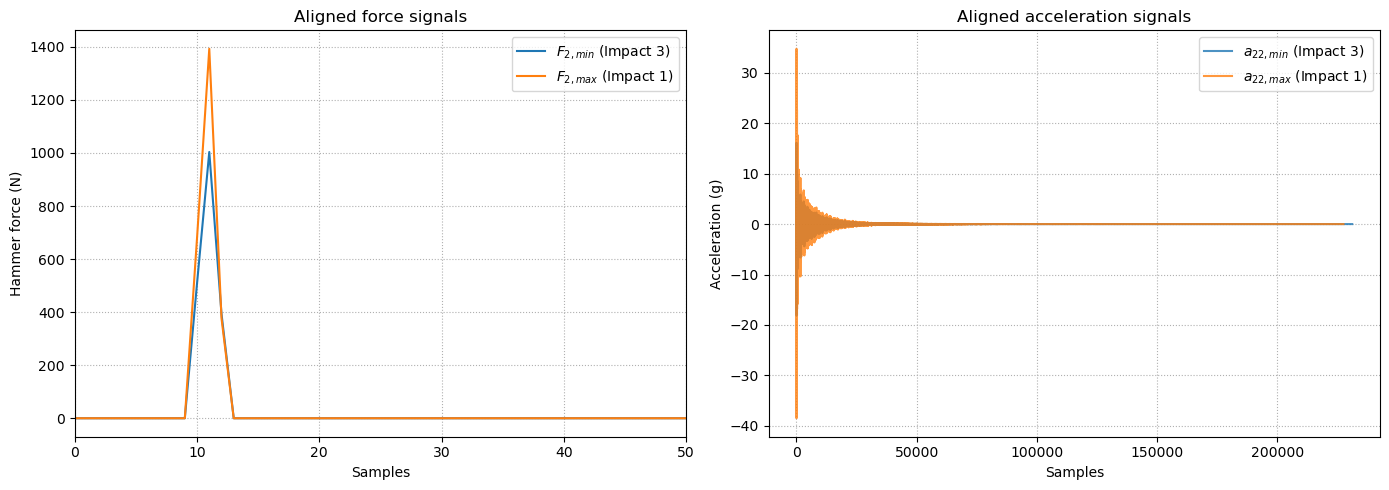

In [15]:
# Truncate the max signal 10 samples before the first triggered index
force_max = F_2[:, max_idx]
acc_max = acc2[:, max_idx]

idx_boolean = force_max > force_trigger
idx_triggered = np.where(idx_boolean)[0]

rec_win = np.zeros(len(force_max))
rec_win[idx_triggered] = 1
f_max_windowed = np.multiply(force_max, rec_win)

f_max_truncated = f_max_windowed[idx_triggered[0]-10:]
acc_max_truncated = acc_max[idx_triggered[0]-10:]

# Same for the minimum peak impact
force_min = F_2[:, min_idx]
acc_min = acc2[:, min_idx]

idx_boolean = force_min > force_trigger
idx_triggered_min = np.where(idx_boolean)[0]

rec_win = np.zeros(len(force_min))
rec_win[idx_triggered_min] = 1
f_min_windowed = np.multiply(force_min, rec_win)

f_min_truncated = f_min_windowed[idx_triggered_min[0]-10:]
acc_min_truncated = acc_min[idx_triggered_min[0]-10:]

# Plot aligned forces
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(f_min_truncated, label=f'$F_{{2,min}}$ (Impact {min_idx+1})')
axes[0].plot(f_max_truncated, label=f'$F_{{2,max}}$ (Impact {max_idx+1})')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Hammer force (N)')
axes[0].set_title('Aligned force signals')
axes[0].set_xlim((0, 50))
axes[0].legend()
axes[0].grid(True, ls=':')

axes[1].plot(acc_min_truncated, label=f'$a_{{22,min}}$ (Impact {min_idx+1})', alpha=0.8)
axes[1].plot(acc_max_truncated, label=f'$a_{{22,max}}$ (Impact {max_idx+1})', alpha=0.8)
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Acceleration (g)')
axes[1].set_title('Aligned acceleration signals')
axes[1].legend()
axes[1].grid(True, ls=':')

plt.tight_layout()
plt.show()

**c. (Exponential window)**. Apply an exponential window to aligned $a_{22,max}$.The exponential window can be calculated as $w(t)=e^{(-\beta t)}$. Compare the windowed and orignal signals with different $\beta$ values. Explain why an exponential window is necessry and what its effect for the modal analysis later on.

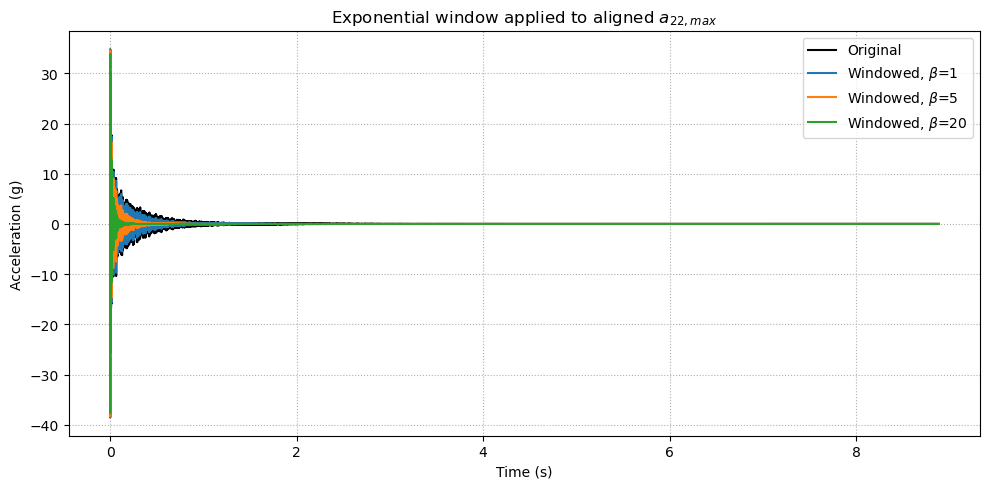

In [16]:
# Create time instances for the aligned acceleration
t_acc = np.arange(len(acc_max_truncated)) / sf

# Exponential window with different beta values
beta_list = [1, 5, 20]

plt.figure(figsize=(10, 5))
plt.plot(t_acc, acc_max_truncated, label='Original', color='k', linewidth=1.5)

for b in beta_list:
    exp_win = np.exp(-b * t_acc)
    acc_windowed = np.multiply(acc_max_truncated, exp_win)
    plt.plot(t_acc, acc_windowed, label=f'Windowed, $\\beta$={b}')

plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.title(r'Exponential window applied to aligned $a_{22,max}$')
plt.legend()
plt.grid(True, ls=':')
plt.tight_layout()
plt.show()

**Comparing with the original signal, the exponential windowed signal shows a faster decay in acceleration, and a larger $\beta$ leads to a faster decay. This accelerated decay makes the output signal closer to the ideal condition, thereby reducing spectral leakage in the frequency domain.**

**However, it also introduced artificial damping, since it forces the signal to decay faster than in reality. This must be accounted for during modal parameter estimation by $\zeta_{n,\text{corrected}} = \zeta_{\text{identified}} - \frac{\beta}{\omega_n}$.**

**d. (Zero-padding)** Caculate the Welch periodogram of the windowed $a_{22,max}$.This time zero-pad the signal to 40 seconds by setting the `nfft` argument in `signal.welch` to the correct value. Please use `plt.xlim` to zoom in to the frequency range that shows the first three natural frequencies. Compare this periodogram with the one in Exercise 1.2.d. What are the main differences and why?

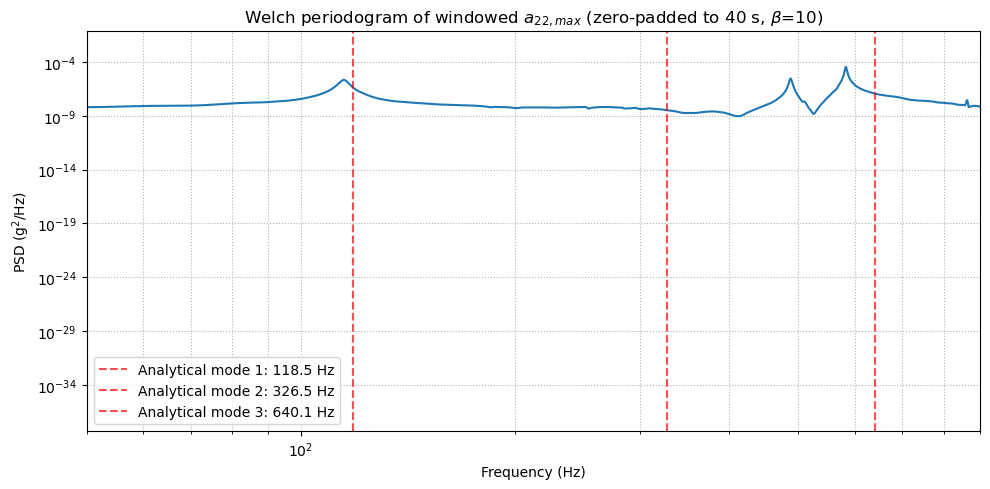

In [17]:
# Apply exponential window with beta = 10 for the periodogram
beta_val = 10
exp_win = np.exp(-beta_val * t_acc)
acc_max_windowed = np.multiply(acc_max_truncated, exp_win)

N_fft = 40 * sf                  # zero-pad to 40 seconds
N_overlap = 0
N_window = len(acc_max_windowed)  # window length = signal length

# Welch periodogram of the windowed signal
fxx, pxx = signal.welch(acc_max_windowed, sf, window='boxcar',
                        nperseg=N_window, noverlap=N_overlap, nfft=N_fft)

plt.figure(figsize=(10, 5))
plt.loglog(fxx, pxx)
plt.xlim(50, 900)

for i, f in enumerate(f_n):
    plt.axvline(f, color='r', linestyle='--', alpha=0.7,
                label=f'Analytical mode {i+1}: {f:.1f} Hz')

plt.xlabel('Frequency (Hz)')
plt.ylabel(r'PSD (g$^2$/Hz)')
plt.title(r'Welch periodogram of windowed $a_{22,max}$ (zero-padded to 40 s, $\beta$=10)')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()

**By comparing the Welch periodogram with and without zero-padding, it can be observed that the curve with zero-padding appears smoother. This is because zero-padding increases the number of frequency samples, leading to a denser representation of the spectrum.**

**The peak frequencies remain unchanged in both cases, which indicates that zero-padding does not alter the actual frequency content of the signal, but only improves the visual resolution of the spectrum.**

**In contrast, the Welch method reduces the frequency resolution due to segmentation and averaging. Zero-padding does not recover this lost resolution, but it makes the spectrum appear more continuous.**

**It can also be observed that the peak amplitudes are slightly lower after zero-padding. This is because the same energy is distributed over more frequency points, resulting in lower values at individual frequency bins.**


# Problem set 2: frequency response functions (FRF)

###  Exercise 2.1. H1 estimator of FRF

**a**. Plot the processed input (force) signal and output (acceleration) signal.

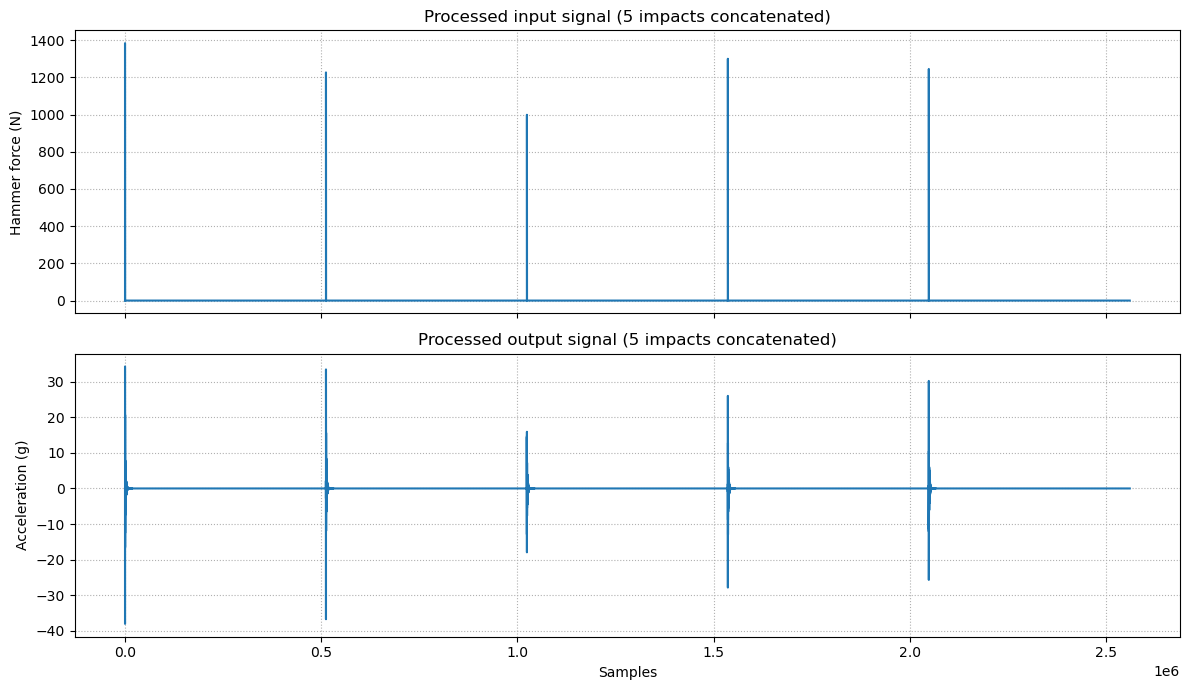

In [18]:
forces = F_2
accs = acc2

force_trigger = 5

# Storage for 20 s zero-padded signals
acc_pad = np.zeros((20 * sf, 5))
impulse_pad = np.zeros((20 * sf, 5))

beta = 10  # exponential window parameter

for ii in range(5):
    impulse = forces[:, ii]
    acc = accs[:, ii]

    # Force window
    idx_boolean = impulse > force_trigger
    idx_triggered = np.where(idx_boolean)[0]
    rec_win = np.zeros(len(impulse))
    rec_win[idx_triggered] = 1
    impulse_windowed = np.multiply(impulse, rec_win)

    # Truncate (align)
    impulse_truncated = impulse_windowed[idx_triggered[0]-10:]
    acc_truncated = acc[idx_triggered[0]-10:]

    # Exponential window
    t_acc = np.arange(len(acc_truncated)) / sf
    exp_win = np.exp(-beta * t_acc)
    acc_windowed = np.multiply(acc_truncated, exp_win)
    impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)

    # Zero-pad to 20 s
    pad_after = 20 * sf - len(acc_truncated)
    acc_pad[:, ii] = np.pad(acc_windowed, (0, pad_after), 'constant')
    impulse_pad[:, ii] = np.pad(impulse_truncated_exp, (0, pad_after), 'constant')

# Concatenate all five impacts
acc_processed = np.hstack([acc_pad[:, i] for i in range(5)])
impulse_processed = np.hstack([impulse_pad[:, i] for i in range(5)])

# Plot processed signals
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(impulse_processed)
axes[0].set_ylabel('Hammer force (N)')
axes[0].set_title('Processed input signal (5 impacts concatenated)')
axes[0].grid(True, ls=':')

axes[1].plot(acc_processed)
axes[1].set_xlabel('Samples')
axes[1].set_ylabel('Acceleration (g)')
axes[1].set_title('Processed output signal (5 impacts concatenated)')
axes[1].grid(True, ls=':')

plt.tight_layout()
plt.show()

**b**. Calculate the PSD, CSD and H1 estimator of the FRF ($\hat{H}_{22}(\omega)$) using the processed input (force) signals and output (acceleration) signals.Plot the amplitude and phase angle of ($\hat{H}_{22}(\omega)$).

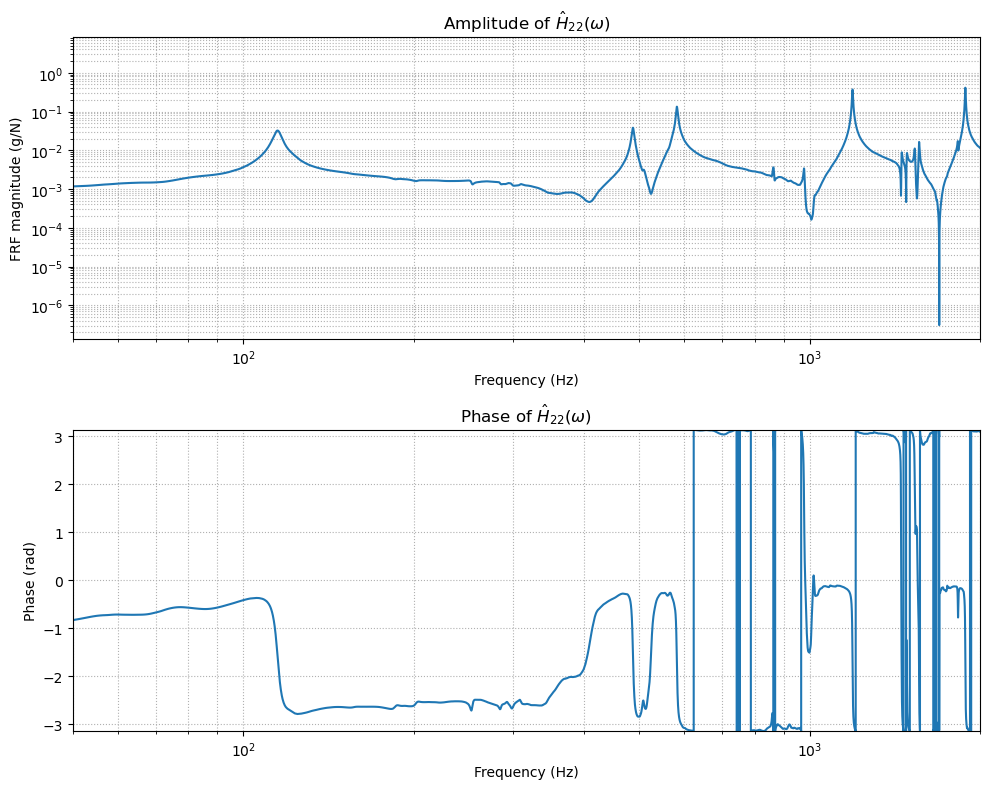

In [21]:
N_fft = 80 * sf      # zero-pad to 80 seconds
N_overlap = 0
N_window = 20 * sf   # segment length = padded signal length

# PSD and CSD using Welch's method
fxx, Sxx = signal.welch(impulse_processed, sf, window='boxcar',
                        nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
_, Sxy = signal.csd(impulse_processed, acc_processed, sf, window='boxcar',
                    nperseg=N_window, noverlap=N_overlap, nfft=N_fft)

# H1 estimator
H1_22 = np.divide(Sxy, Sxx)

# Plot FRF amplitude and phase
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].loglog(fxx, np.abs(H1_22))
axes[0].set_xlim(50, 2000)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('FRF magnitude (g/N)')
axes[0].set_title(r'Amplitude of $\hat{H}_{22}(\omega)$')
axes[0].grid(True, which='both', ls=':')

axes[1].semilogx(fxx, np.angle(H1_22))
axes[1].set_xlim(50, 2000)
axes[1].set_ylim(-3.14, 3.14)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title(r'Phase of $\hat{H}_{22}(\omega)$')
axes[1].grid(True, which='both', ls=':')

plt.tight_layout()
plt.show()

### Exercise 2.2. FRF matrix
**a.** How many FRFs can you obtain from the data collected in Lab Session 1? Which are the driving-point FRFs and which are the transfer FRFs?

**9 FRFs. The driving-point FRFs are $H_{11}$, $H_{22}$ and $H_{33}$, which represent the response at the same location as the excitation. The transfer FRFs are $H_{12}$, $H_{13}$, $H_{21}$, $H_{23}$, $H_{31}$ and $H_{32}$, which represent the response at different locations from the excitation.**

**b**. For the hammer impact at position 1, caluclate the plot the driving-point FRF $\hat{H}_{11}(\omega)$ and one tranfer FRF of your choice. Explain

- The main differences between $\hat{H}_{11}(\omega)$ and $\hat{H}_{22}(\omega)$, and

- The main differences between the driving-point and transfer FRFs

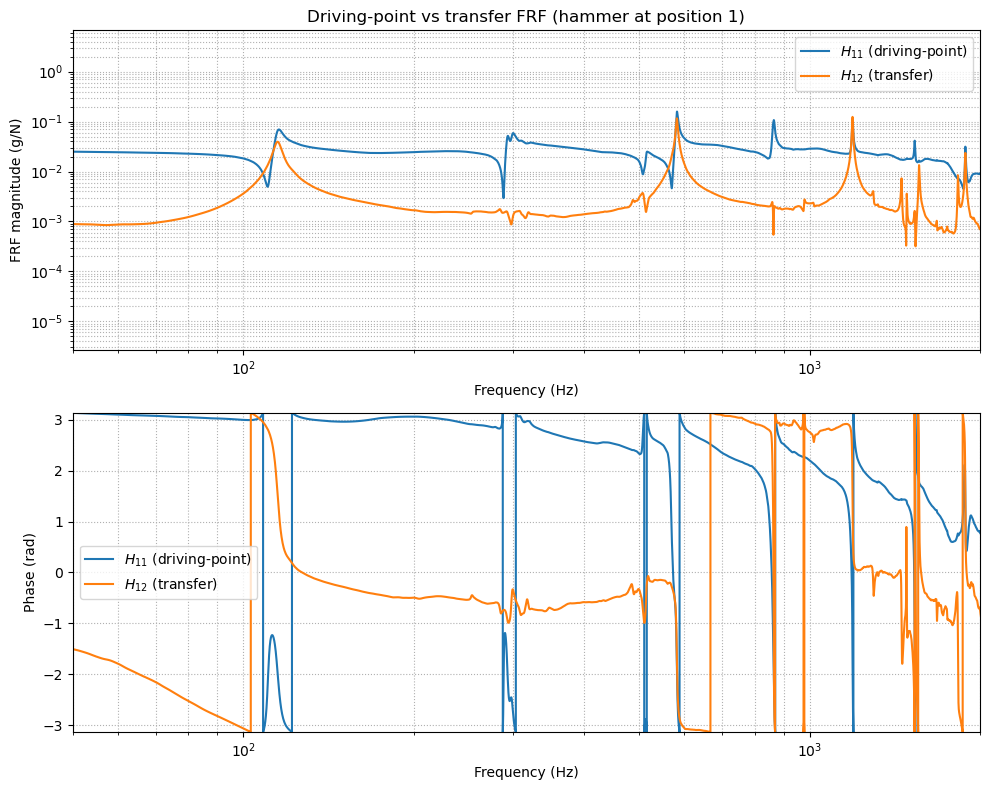

In [22]:
# Read the five repeated impacts for hammer position 1
data_acc1T1 = pd.read_csv('data1/acc1T1.csv', skiprows=3).to_numpy()
data_acc1T2 = pd.read_csv('data1/acc1T2.csv', skiprows=3).to_numpy()
data_acc1T3 = pd.read_csv('data1/acc1T3.csv', skiprows=3).to_numpy()
data_acc1T4 = pd.read_csv('data1/acc1T4.csv', skiprows=3).to_numpy()
data_acc1T5 = pd.read_csv('data1/acc1T5.csv', skiprows=3).to_numpy()

# Forces at position 1
forces_1 = np.stack((
    data_acc1T1[:, 1], data_acc1T2[:, 1], data_acc1T3[:, 1],
    data_acc1T4[:, 1], data_acc1T5[:, 1]
), axis=-1)

# H11: acceleration at position 1 (column index 3)
accs_11 = np.stack((
    data_acc1T1[:, 3], data_acc1T2[:, 3], data_acc1T3[:, 3],
    data_acc1T4[:, 3], data_acc1T5[:, 3]
), axis=-1)

# H12: acceleration at position 2 (column index 5) - transfer FRF
accs_12 = np.stack((
    data_acc1T1[:, 5], data_acc1T2[:, 5], data_acc1T3[:, 5],
    data_acc1T4[:, 5], data_acc1T5[:, 5]
), axis=-1)

force_trigger = 50
beta = 10

def build_processed_signals(forces, accs):
    acc_pad = np.zeros((20 * sf, 5))
    impulse_pad = np.zeros((20 * sf, 5))
    for ii in range(5):
        impulse = forces[:, ii]
        acc = accs[:, ii]
        idx_boolean = impulse > force_trigger
        idx_triggered = np.where(idx_boolean)[0]
        rec_win = np.zeros(len(impulse))
        rec_win[idx_triggered] = 1
        impulse_windowed = np.multiply(impulse, rec_win)
        start_idx = max(idx_triggered[0] - 10, 0)
        impulse_truncated = impulse_windowed[start_idx:]
        acc_truncated = acc[start_idx:]
        t_acc = np.arange(len(acc_truncated)) / sf
        exp_win = np.exp(-beta * t_acc)
        acc_windowed = np.multiply(acc_truncated, exp_win)
        impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)
        pad_after = 20 * sf - len(acc_truncated)
        acc_pad[:, ii] = np.pad(acc_windowed, (0, pad_after), 'constant')
        impulse_pad[:, ii] = np.pad(impulse_truncated_exp, (0, pad_after), 'constant')
    acc_proc = np.hstack([acc_pad[:, i] for i in range(5)])
    imp_proc = np.hstack([impulse_pad[:, i] for i in range(5)])
    return imp_proc, acc_proc

# Process H11 and H12
imp_11, acc_11 = build_processed_signals(forces_1, accs_11)
imp_12, acc_12 = build_processed_signals(forces_1, accs_12)

# Compute FRFs
N_fft = 80 * sf
N_overlap = 0
N_window = 20 * sf

f11, Sxx_11 = signal.welch(imp_11, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
_, Sxy_11 = signal.csd(imp_11, acc_11, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
H11 = np.divide(Sxy_11, Sxx_11)

f12, Sxx_12 = signal.welch(imp_12, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
_, Sxy_12 = signal.csd(imp_12, acc_12, sf, window='boxcar', nperseg=N_window, noverlap=N_overlap, nfft=N_fft)
H12 = np.divide(Sxy_12, Sxx_12)

# Plot amplitude comparison
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].loglog(f11, np.abs(H11), label=r'$H_{11}$ (driving-point)')
axes[0].loglog(f12, np.abs(H12), label=r'$H_{12}$ (transfer)')
axes[0].set_xlim(50, 2000)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('FRF magnitude (g/N)')
axes[0].set_title('Driving-point vs transfer FRF (hammer at position 1)')
axes[0].legend()
axes[0].grid(True, which='both', ls=':')

# Plot phase comparison
axes[1].semilogx(f11, np.angle(H11), label=r'$H_{11}$ (driving-point)')
axes[1].semilogx(f12, np.angle(H12), label=r'$H_{12}$ (transfer)')
axes[1].set_xlim(50, 2000)
axes[1].set_ylim(-3.14, 3.14)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].legend()
axes[1].grid(True, which='both', ls=':')

plt.tight_layout()
plt.show()

**From the following equation:**
$$
H_{xy}(\omega) = \sum_{n} \frac{U_n(x)\,U_n(y)}{(\omega_n^2 - \omega^2) + i(2\omega \omega_n \zeta_n)}
$$

**The main differences between $\hat{H}_{11}(\omega)$ and $\hat{H}_{22}(\omega)$ are that The mode shapes $U_{n}$ vary with location, which leads to different peak amplitudes in the FRFs. Moreover, due to the superposition of multiple modes, the interaction between modes differs at each location, resulting in different antiresonance frequencies.**

**From the plots between the driving-point and transfer FRFs like $\hat{H}_{11}(\omega)$ and $\hat{H}_{12}(\omega)$, it can be observed that the driving-point FRFs are cleaner than the transfer FRFs. In some cases, the antiresonances in the transfer FRFs are even not clearly visible. This can be explained by the expressions of the FRFs: the numerator of the driving-point FRF is the square of the mode shape at the same location, while the transfer FRF involves the product of mode shapes at two different locations, which may have opposite signs. As a result, the modal interaction in transfer FRFs is more complex, leading to less stable or less pronounced antiresonances.**

# Problem set 3: Modal parameter identification and statistic model updating.


### Exercise 3.1. Natural frequencies and damping ratio

**a**. Use a figure to show the $N$ measurement positions. Calculate the $N$ FRFs and plot them in one figure.

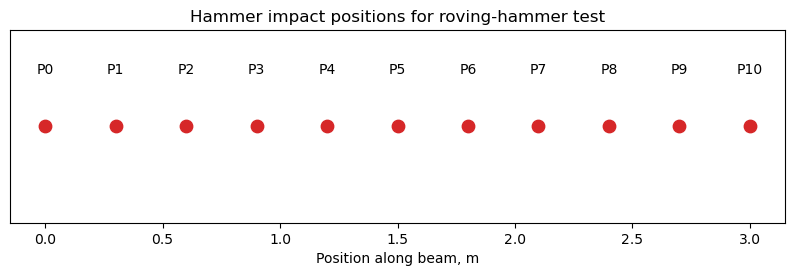

c:\Users\wasay\tudelft-conda\envs\mude-base\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


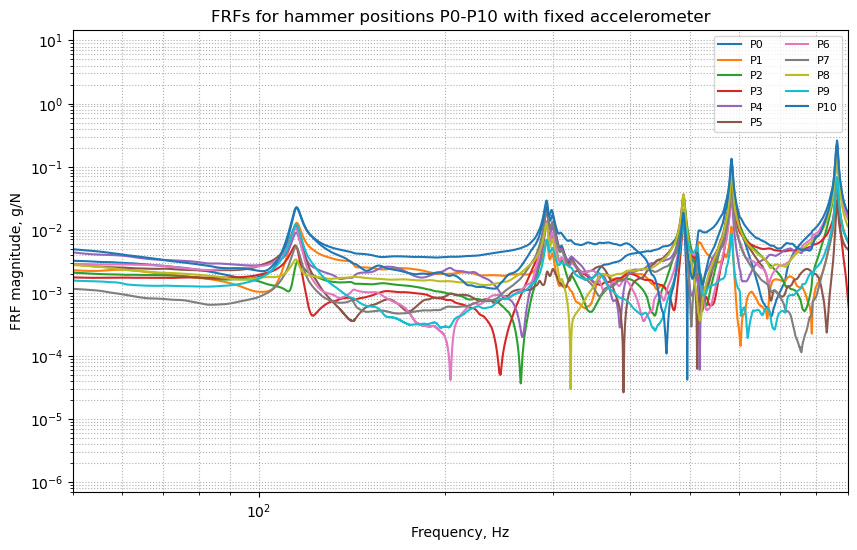

In [24]:
# Hammer positions in data2
positions = list(range(11))   # P0 ... P10

x_positions = np.linspace(0, 3.0, 11)


# Choose fixed accelerometer:
# acc1 -> 3
# acc2 -> 5
# acc3 -> 7
acc_col = 3

sf = 25600
force_trigger = 50
beta = 10
N_window = 20 * sf
N_overlap = 0
N_fft = 80 * sf

def build_frf_for_position(pos, acc_col):
    # Read the five repeated impacts for one hammer position
    repeats = []
    for tt in range(1, 6):
        path = f'data2/P{pos}T{tt}.csv'
        data = pd.read_csv(path, skiprows=4, header=None).to_numpy()
        repeats.append(data)

    # Stack five force and acceleration signals
    forces = np.stack([d[:, 1] for d in repeats], axis=-1)
    accs   = np.stack([d[:, acc_col] for d in repeats], axis=-1)

    # Storage for 20 s padded signals
    acc_pad = np.zeros((20 * sf, 5))
    impulse_pad = np.zeros((20 * sf, 5))

    for ii in range(5):
        impulse = forces[:, ii]
        acc = accs[:, ii]

        idx_boolean = impulse > force_trigger
        idx_triggered = np.where(idx_boolean)[0]

        rec_win = np.zeros(len(impulse))
        rec_win[idx_triggered] = 1

        impulse_windowed = np.multiply(impulse, rec_win)

        start_idx = max(idx_triggered[0] - 10, 0)
        impulse_truncated = impulse_windowed[start_idx:]
        acc_truncated = acc[start_idx:]

        t_acc = np.arange(len(acc_truncated)) / sf
        exp_win = np.exp(-beta * t_acc)

        acc_windowed = np.multiply(acc_truncated, exp_win)
        impulse_truncated_exp = np.multiply(impulse_truncated, exp_win)

        pad_after = 20 * sf - len(acc_truncated)
        acc_pad[:, ii] = np.pad(acc_windowed, (0, pad_after), 'constant')
        impulse_pad[:, ii] = np.pad(impulse_truncated_exp, (0, pad_after), 'constant')

    acc_processed = np.hstack((acc_pad[:, 0], acc_pad[:, 1], acc_pad[:, 2], acc_pad[:, 3], acc_pad[:, 4]))
    impulse_processed = np.hstack((impulse_pad[:, 0], impulse_pad[:, 1], impulse_pad[:, 2], impulse_pad[:, 3], impulse_pad[:, 4]))

    # Welch PSD/CSD and H1
    fxx, Sxx = signal.welch(
        impulse_processed,
        sf,
        window='boxcar',
        nperseg=N_window,
        noverlap=N_overlap,
        nfft=N_fft
    )

    fxy, Sxy = signal.csd(
        impulse_processed,
        acc_processed,
        sf,
        window='boxcar',
        nperseg=N_window,
        noverlap=N_overlap,
        nfft=N_fft
    )

    H1 = np.divide(Sxy, Sxx)
    return fxx, H1

# Compute FRFs for all hammer positions
frfs = []
for pos in positions:
    fxx, H1 = build_frf_for_position(pos, acc_col)
    frfs.append(H1)

frfs = np.array(frfs)

# Plot measurement positions
plt.figure(figsize=(10, 2.5))
plt.scatter(x_positions, np.ones_like(x_positions), s=80, color='tab:red')
for i, xp in enumerate(x_positions):
    plt.text(xp, 1.03, f'P{i}', ha='center')
plt.yticks([])
plt.xlabel('Position along beam, m')
plt.title('Hammer impact positions for roving-hammer test')
plt.show()

# Plot all FRFs in one figure
plt.figure(figsize=(10, 6))
for i, H1 in enumerate(frfs):
    plt.loglog(fxx, np.abs(H1), label=f'P{i}')
plt.xlim(50, 900)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magnitude, g/N')
plt.title(r'FRFs for hammer positions P0-P10 with fixed accelerometer')
plt.legend(ncol=2, fontsize=8)
plt.grid(True, which='both', ls=':')
plt.show()


**b**. Identify the first three natural frequencies of the beam bending modes from one of the FRFs you showed in Exercise 3.1.a (choose one as you wish). Compare the first three natural frequencies obtained from the FRF with those calculated from the analytical model (Exercise 1.2.b) and discuss what the possilbe causes for the discrepencies are.

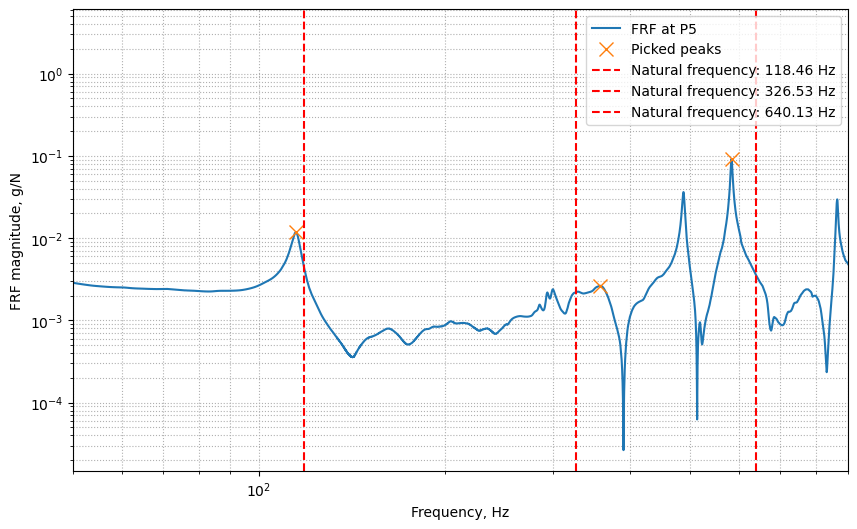

Chosen FRF: P5
First three natural frequencies: 114.88 Hz, 357.62 Hz, 583.27 Hz


In [39]:
# Choose one FRF from 3.1a
frf_idx = 5              # P5, change if another FRF is clearer
frf = np.abs(frfs[frf_idx])

# Frequency bands around the first three bending modes
bands = [(80, 160), (250, 380), (550, 750)]

peak_idx = []
natural_freqs = []

for fmin, fmax in bands:
    mask = (fxx >= fmin) & (fxx <= fmax)
    idx_local = np.argmax(frf[mask])
    idx_global = np.where(mask)[0][idx_local]
    peak_idx.append(idx_global)
    natural_freqs.append(fxx[idx_global])

peak_idx = np.array(peak_idx)
natural_freqs = np.array(natural_freqs)

# Plot the chosen FRF and mark the picked peaks
plt.figure(figsize=(10, 6))
plt.loglog(fxx, frf, label=f'FRF at P{frf_idx}')
plt.plot(fxx[peak_idx], frf[peak_idx], 'x', markersize=10, label='Picked peaks')

# Mark the natural frequencies on the plot
for f in f_n:
    plt.axvline(f, color='r', linestyle='--', label=f'Natural frequency: {f:.2f} Hz')

plt.xlim(50, 900)
plt.xlabel('Frequency, Hz')
plt.ylabel('FRF magnitude, g/N')
plt.legend()
plt.grid(True, which='both', ls=':')
plt.show()

print(f'Chosen FRF: P{frf_idx}')
print(f'First three natural frequencies: {natural_freqs[0]:.2f} Hz, {natural_freqs[1]:.2f} Hz, {natural_freqs[2]:.2f} Hz')


**Discrepencies between measured and analytical natural frequencies**

*1. Euler-Bernoulli model limitations:* The model we consider is a simple model which neglects shear deformations and rotary inertia, which are considered in a slightly more complex model like the Timoshenko beam model. The more complex model we use for analytical calculations, more closer it would be to real world values.

*2. Boundary conditions:* The experiment uses a suspended beam (hung by cables), which approximates but does not replicate the ideal free-free conditions.

*3. Beam length imperfections:* Small errors in beam length have a significant effect on natural frequencies as it is proportional to $1/l^2$.

*4. Cross-section properties:* Manufacturing tolerances, wear, or measurement direction could introduce deviations.

*5. Additional vibration modes:* Some peaks in the FRF may correspond to these other mode types rather than vertical bending.

**c**. Estimate the damping ratio of the first three natural frequencies using the same FRF as in Exercise 3.1.b. For this, you can use the half-power bandwidth method.

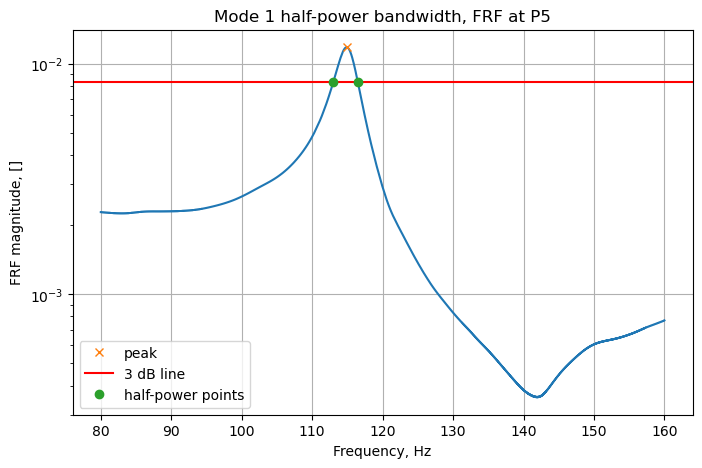

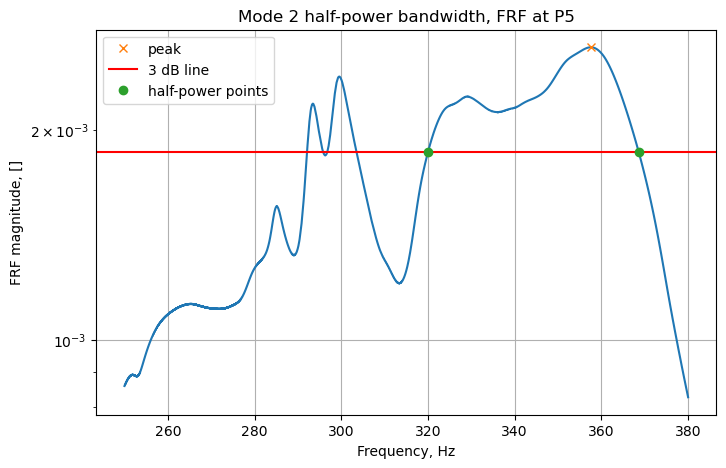

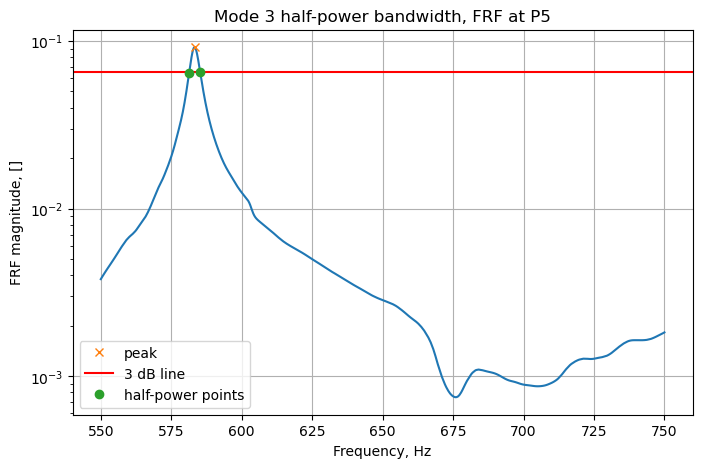

Mode 1:
  natural frequency = 114.88 Hz
  damping ratio     = 0.015125
  corrected damping = 0.001271
Mode 2:
  natural frequency = 357.62 Hz
  damping ratio     = 0.067983
  corrected damping = 0.063533
Mode 3:
  natural frequency = 583.27 Hz
  damping ratio     = 0.003365
  corrected damping = 0.000636


In [40]:
# Choose one FRF from 3.1a
frf_idx = 5                 # example: P5
frf = np.abs(frfs[frf_idx])

# Frequency bands for the first three bending modes
bands = [(80, 160), (250, 380), (550, 750)]

damping_ratios = []
damping_ratios_corrected = []
natural_freqs = []

for i, (fmin, fmax) in enumerate(bands, start=1):
    # Restrict to one mode band
    mask = (fxx >= fmin) & (fxx <= fmax)
    f_band = fxx[mask]
    frf_band = frf[mask]

    # Peak in this band
    peak_local = np.argmax(frf_band)
    f_r = f_band[peak_local]
    natural_freqs.append(f_r)

    # 3 dB level
    peak_3db = frf_band[peak_local] / np.sqrt(2)

    # Same idea as example: difference to half-power line
    diff_3db = -np.abs(frf_band - peak_3db)

    # Left and right half-power points
    left_idx = np.argmax(diff_3db[:peak_local])
    right_idx = peak_local + 1 + np.argmax(diff_3db[peak_local + 1:])

    f_1 = f_band[left_idx]
    f_2 = f_band[right_idx]
    delta_f = f_2 - f_1

    # Damping ratio
    zeta = delta_f / (2 * f_r)
    zeta_c = zeta - beta / (2 * np.pi * f_r)

    damping_ratios.append(zeta)
    damping_ratios_corrected.append(zeta_c)

    # Plot for this mode
    plt.figure(figsize=(8, 5))
    plt.semilogy(f_band, frf_band)
    plt.plot(f_r, frf_band[peak_local], "x", label='peak')
    plt.axhline(y=peak_3db, color='r', linestyle='-', label='3 dB line')
    plt.plot([f_1, f_2], [frf_band[left_idx], frf_band[right_idx]], "o", label='half-power points')
    plt.xlabel('Frequency, Hz')
    plt.ylabel('FRF magnitude, []')
    plt.title(f'Mode {i} half-power bandwidth, FRF at P{frf_idx}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Print results
for i in range(3):
    print(f"Mode {i+1}:")
    print(f"  natural frequency = {natural_freqs[i]:.2f} Hz")
    print(f"  damping ratio     = {damping_ratios[i]:.6f}")
    print(f"  corrected damping = {damping_ratios_corrected[i]:.6f}")


**Observations on damping estimation**

The corrected damping ratios for modes 1 and 3 are in the expected range for a steel beam (on the order of 0.001). The damping ratio for mode 2 appears significantly higher, which may indicate that the half-power bandwidth method is less reliable for this mode. This can happen if the peak is not well-separated from neighbouring modes or if the measurement position coincides with a region of low modal amplitude for that mode, leading to a poor signal-to-noise ratio.

The correction for the exponential window is applied as: $\zeta_{corrected} = \zeta_{measured} - \frac{\beta}{2\pi f_n}$. This subtracts the artificial damping introduced by the exponential window ($\beta$ = 10 in our case).

### Exercise 3.2. Mode shapes

**a.** Plot the modal amplitude $a_1$ at the $N$ positions to show the first mode shape. Note that you should scale the modal amplitude $a_1$ so that its maximum amplitude is 100.

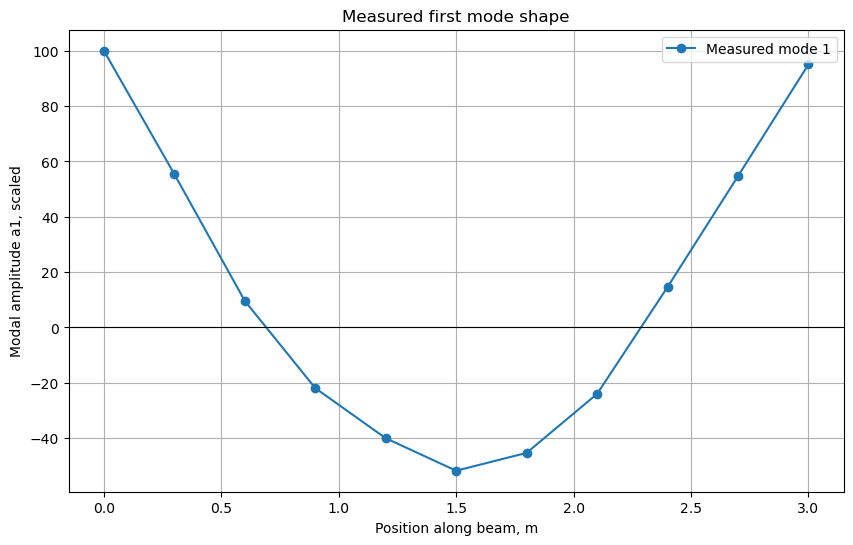

Median first-mode frequency = 114.98 Hz
Median corrected damping ratio = 0.001429


In [41]:
# Mode band
first_mode_band = (80, 160)

n_pos = frfs.shape[0]

f1_each = np.zeros(n_pos)
zeta1_each = np.zeros(n_pos)
H1_peak_each = np.zeros(n_pos, dtype=complex)

for p in range(n_pos):
    Hp = frfs[p]
    Hp_mag = np.abs(Hp)

    mask = (fxx >= first_mode_band[0]) & (fxx <= first_mode_band[1])
    f_band = fxx[mask]
    H_band = Hp[mask]
    H_mag_band = Hp_mag[mask]

    peak_local = np.argmax(H_mag_band)
    peak_global = np.where(mask)[0][peak_local]

    f_r = fxx[peak_global]
    f1_each[p] = f_r
    H1_peak_each[p] = frfs[p, peak_global]

    peak_3db = H_mag_band[peak_local] / np.sqrt(2)

    left_idx = np.argmin(np.abs(H_mag_band[:peak_local] - peak_3db))
    right_idx = peak_local + 1 + np.argmin(np.abs(H_mag_band[peak_local + 1:] - peak_3db))

    f_1 = f_band[left_idx]
    f_2 = f_band[right_idx]

    zeta_raw = (f_2 - f_1) / (2 * f_r)
    zeta_corr = zeta_raw - beta / (2 * np.pi * f_r)

    if zeta_corr <= 0:
        zeta_corr = zeta_raw

    zeta1_each[p] = zeta_corr

# Use one global damping estimate for mode 1
zeta1_global = np.median(zeta1_each)
Q1 = 1 / (2 * zeta1_global)

# Modal amplitude a1 at each position
a1_complex = H1_peak_each / (1j * Q1)
a1_measured = np.real(a1_complex)

# Normalize so max absolute amplitude is 100
mode1_measured = 100 * a1_measured / np.max(np.abs(a1_measured))

# Optional sign convention for plotting
if mode1_measured[0] < 0:
    mode1_measured = -mode1_measured

plt.figure(figsize=(10, 6))
plt.plot(x_positions, mode1_measured, 'o-', label='Measured mode 1')
plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel('Position along beam, m')
plt.ylabel('Modal amplitude a1, scaled')
plt.title('Measured first mode shape')
plt.grid(True)
plt.legend()
plt.show()

print(f'Median first-mode frequency = {np.median(f1_each):.2f} Hz')
print(f'Median corrected damping ratio = {zeta1_global:.6f}')


**b.** Calculate and show the first three analytical mode shapes of a free-free beam. Note that you should scale each mode shape $W_n(x)$ so that its maximum amplitude is 100.

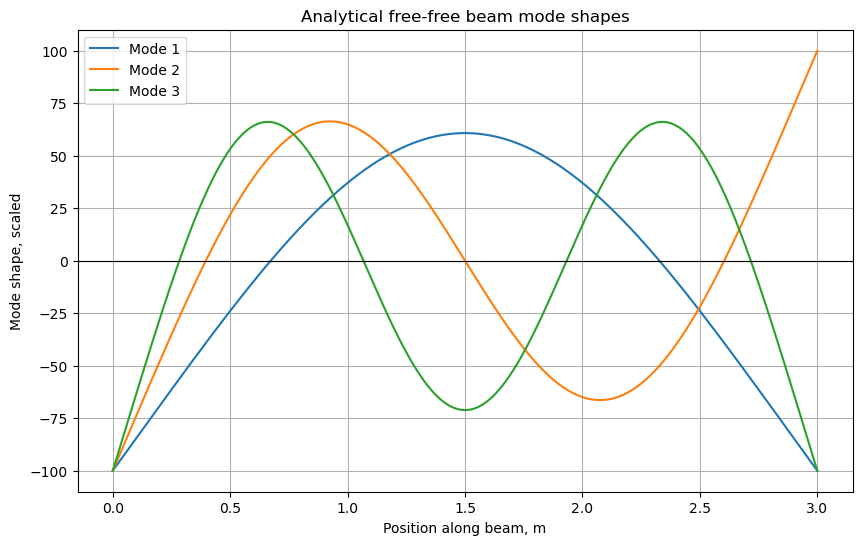

In [42]:
L = 3.0
betaL = np.array([4.730041, 7.853205, 10.995608])

def free_free_mode(betaL_n, x, L):
    beta_n = betaL_n / L
    alpha_n = (np.sin(beta_n * L) - np.sinh(beta_n * L)) / (np.cosh(beta_n * L) - np.cos(beta_n * L))
    W = np.sin(beta_n * x) + np.sinh(beta_n * x) + alpha_n * (np.cos(beta_n * x) + np.cosh(beta_n * x))
    return 100 * W / np.max(np.abs(W))

x_plot = np.linspace(0, L, 400)

mode1_analytic_plot = free_free_mode(betaL[0], x_plot, L)
mode2_analytic_plot = free_free_mode(betaL[1], x_plot, L)
mode3_analytic_plot = free_free_mode(betaL[2], x_plot, L)

# Values at the measurement positions for 3.2c
mode1_analytic = free_free_mode(betaL[0], x_positions, L)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, mode1_analytic_plot, label='Mode 1')
plt.plot(x_plot, mode2_analytic_plot, label='Mode 2')
plt.plot(x_plot, mode3_analytic_plot, label='Mode 3')
plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel('Position along beam, m')
plt.ylabel('Mode shape, scaled')
plt.title('Analytical free-free beam mode shapes')
plt.grid(True)
plt.legend()
plt.show()


**c.** Plot the measured (Exercise 3.2.a) and analytical (Exercise 3.2.b) model shapes for the first mode in one figure. Caculate the Modal Assurance Criterion (MAC) value between the two mode shapes. Explain what this MAC value indicates.

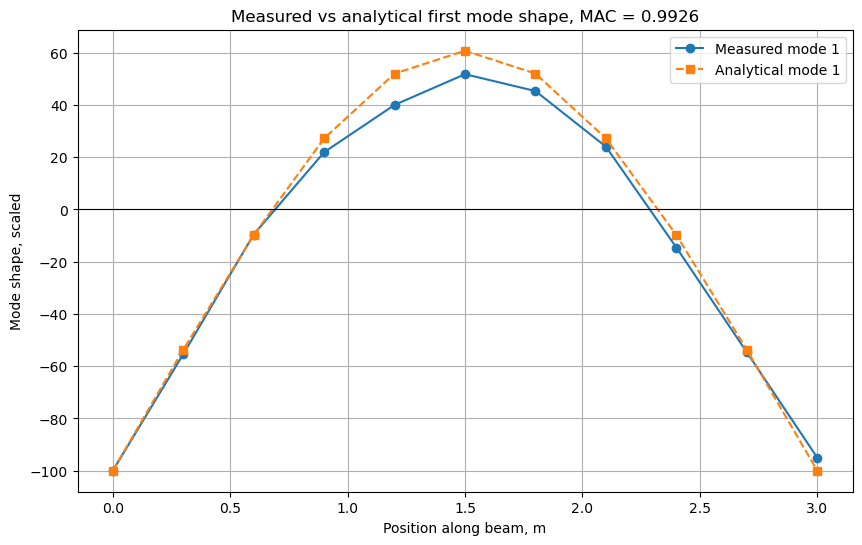

MAC between measured and analytical first mode = 0.9926


In [43]:
# Flip measured mode if needed so the plot matches the analytical orientation
mode1_measured_plot = mode1_measured.copy()
if np.vdot(mode1_measured_plot, mode1_analytic) < 0:
    mode1_measured_plot = -mode1_measured_plot

phi_meas = mode1_measured_plot.astype(complex)
phi_ana = mode1_analytic.astype(complex)

MAC_11 = np.abs(np.vdot(phi_meas, phi_ana))**2 / (np.vdot(phi_meas, phi_meas) * np.vdot(phi_ana, phi_ana))
MAC_11 = np.real(MAC_11)

plt.figure(figsize=(10, 6))
plt.plot(x_positions, mode1_measured_plot, 'o-', label='Measured mode 1')
plt.plot(x_positions, mode1_analytic, 's--', label='Analytical mode 1')
plt.axhline(0, color='k', linewidth=0.8)
plt.xlabel('Position along beam, m')
plt.ylabel('Mode shape, scaled')
plt.title(f'Measured vs analytical first mode shape, MAC = {MAC_11:.4f}')
plt.grid(True)
plt.legend()
plt.show()

print(f'MAC between measured and analytical first mode = {MAC_11:.4f}')


**Interpretation of MAC value**

The Modal Assurance Criterion (MAC) quantifies the degree of correlation between two mode shape vectors. A MAC value of 1.0 indicates prefectly correlated mode shapes whereas 0.0 indicates completely uncorrelated mode shapes.

Our MAC value of 0.9926 indicates perfect similarity between experimentally measured first mode shape and analytical free-free beam model. This validates the experimental setup (hammer impacts on 11 positions) and the Euler-Bernoulli beam model for the first bending mode. The small deviation from 1.0 can be attributed to measurement noise, slight imperfections in the boundary conditions, and the finite number of measurement points.

### Exercise 3.3. Analysis of measurement uncertainty ï¼ˆoptionalï¼‰

Compare the FRFs measured with hits at ideal and deviated locations and analyze how the hammer hitting positions may influence the measurement results.

In [44]:
# Your answer